<a href="https://colab.research.google.com/github/georginadd/EMSC2010_major_project/blob/main/EMSC2010_Major_Assignment_u7925896.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EMSC2010 Major Assignment - How do tidal and environmental conditions influence phosphate concentrations in reef habitats over time?


# Project Overview

**Dataset selection & cleaning**

Data was found from BCO-DMO; “Experimental and in situ seawater nutrient data collected as part of a study of pCO2 variability on the reef-building coral Pocillopora damicornis conducted at Heron Island Research Station, Heron Island, southern Great Barrier Reef in 2021”. This was downloaded as a csv file and loaded into the colab notebook.

**Citation:** Barott, K., Brown, K. T. (2023). Experimental and in situ seawater nutrient data collected as part of a study of pCO2 variability on the reef-building coral Pocillopora damicornis conducted at Heron Island Research Station, Heron Island, southern Great Barrier Reef in 2021. Biological and Chemical Oceanography Data Management Office (BCO-DMO). (Version 1) Version Date 2022-12-20. doi:10.26008/1912/bco-dmo.885669.1


**METADATA**: See pdf file in repository.


AIM:
To investigate how phosphate conditions change over time, due to shorter and longer term processes including tides and climate.

Understanding the factors controlling ocean phosphate concentrations is important as it is a biolimiting nutrient, and forms the basis of the global food web. It controls the oceans biological pump and global carbon cycling.

**Load in and clean dataset**

In [81]:
import pandas as pd
nutrients = pd.read_csv("infield_nutrients.csv")

# create a continuous time variable
nutrients['DateTime'] = pd.to_datetime(nutrients['Date'].astype(str) + ' ' + nutrients['Time'].astype(str))

nutrients['Decimal_Time'] = (nutrients['DateTime'] - nutrients['DateTime'].min()
).dt.total_seconds() / (24*60*60)
print(nutrients[['Date', 'Time', 'Decimal_Time']].head())




         Date   Time  Decimal_Time
0  2021-01-15  09:30       0.00000
1  2021-01-15  09:30       0.00000
2  2021-01-15  09:30       0.00000
3  2021-01-15  10:15       0.03125
4  2021-01-15  10:15       0.03125


Install relevant packages

In [17]:
!pip install bambi #system command to install bambi package

# Import required packages for data handling, plotting, modelling, and model comparison

import numpy as np
import matplotlib.pyplot as plt
import bambi as bmb
import arviz as az
import pandas as pd

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 237.8/237.8 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 584.2/584.2 kB 50.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 105.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.4/259.4 kB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 87.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.9/179.9 kB 19.7 MB/s eta 0:00:00
  Attempting uninstall: pytensor
    Found existing installation: pytensor 2.38.3
    Uninstalling pytensor-2.38.3:
      Successfully uninstalled pytensor-2.38.3
  Attempting uninstall: arviz
    Found existing installation: arviz 0.22.0
    Uninstalling arviz-0.22.0:
      Successfully uninstalled arviz-0.22.0
  Attempting uninstall: pymc
    Found existing 

# Time series analysis

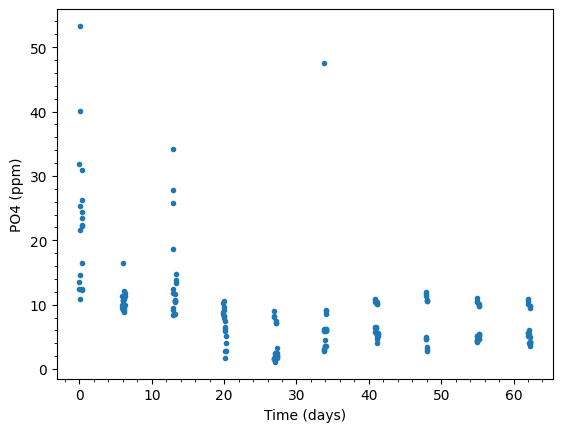

In [135]:
plt.plot(nutrients.Decimal_Time,nutrients.PO4_P,'.') #plot the data
plt.xlabel('Time (days)') #label the x-axis
plt.ylabel('PO4 (ppm)') #label the y-axis
plt.minorticks_on() #add minorticks to the plot

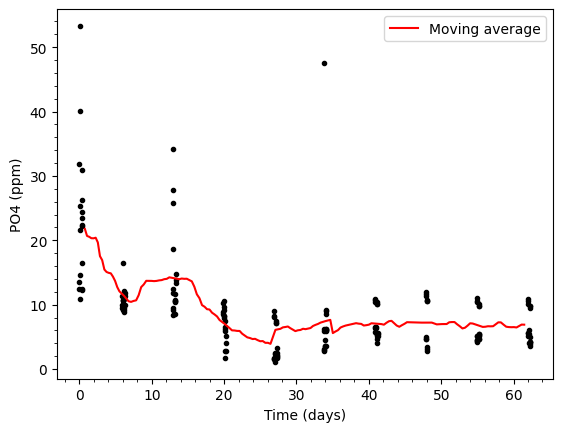

In [136]:
# calculate moving average
def moving_average(x, w):
    return np.convolve(x, np.ones(w), 'valid') / w

w = 20 # length of the moving average
PO4_s = moving_average(nutrients.PO4_P, w) # process the signal
Time_s = moving_average(nutrients.Decimal_Time, w) # process the times

plt.plot(nutrients.Decimal_Time,nutrients.PO4_P, '.k') #plot the data
plt.plot(Time_s,PO4_s,'r', label="Moving average")
plt.legend()

plt.xlabel('Time (days)')
plt.ylabel('PO4 (ppm)')
plt.minorticks_on()

In [159]:
# Using Bayesian regression models to decide what polynomial is best to fit to the data
# Scale the x variable (Year), so it has a mean of 0 and standard deviation of 1
# This helps the Bayesian correlation and regression models sample more reliably

nutrients["x_scaled"] = (nutrients.Decimal_Time - np.mean(nutrients.Decimal_Time)) / np.std(nutrients.Decimal_Time)

# Create polynomial terms for testing increasingly complex regression models

nutrients["x2_scaled"] = nutrients["x_scaled"] ** 2
nutrients["x3_scaled"] = nutrients["x_scaled"] ** 3
nutrients["x4_scaled"] = nutrients["x_scaled"] ** 4

#added polynomial terms to allow for curved relationships, and compared the fitted models.

# Fit a straight-line model (first-order polynomial)

model_linear = bmb.Model("PO4_P ~ x_scaled * Habitat", nutrients)
idata_linear = model_linear.fit(idata_kwargs={"log_likelihood": True}, progressbar=False, nonnegative=True) #"nonnegative=True" here means that negative values are excluded from the model, as while polynomial functions can contain negative values a reef cannot have less than 0 coral cover

# Fit a quadratic model (second-order polynomial)

model_quadratic = bmb.Model("PO4_P ~ x_scaled + x2_scaled * Habitat", nutrients)
idata_quadratic = model_quadratic.fit(idata_kwargs={"log_likelihood": True}, progressbar=False, nonnegative=True)

# Fit a cubic model (third-order polynomial)

model_cubic = bmb.Model("PO4_P ~ x_scaled + x2_scaled + x3_scaled * Habitat", nutrients)
idata_cubic = model_cubic.fit(idata_kwargs={"log_likelihood": True}, progressbar=False, nonnegative=True)

# Fit a quartic model (fourth-order polynomial)

model_quartic = bmb.Model("PO4_P ~ x_scaled + x2_scaled + x3_scaled + x4_scaled * Habitat", nutrients)
idata_quartic = model_quartic.fit(idata_kwargs={"log_likelihood": True}, progressbar=False, nonnegative=True)

#false progress bars so that once in the Github it wasn't invalid

# Compare all fitted models using Arviz model comparison
# The model with rank 0 is considered the best-fitting model

az.compare({"linear": idata_linear, "quadratic": idata_quadratic, "cubic": idata_cubic, "quartic": idata_quartic})

/usr/local/lib/python3.12/dist-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
/usr/local/lib/python3.12/dist-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
/usr/local/lib/python3.12/dist-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
/usr/local/lib/python3.12/dist-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  ret

,rank,elpd,p,elpd_diff,weight,se,dse,warning
cubic,0,-550.0,17.5,0.0,0.25,33.0,0.0,True
quartic,1,-550.0,18.1,-0.0,0.65,33.0,1.5,True
quadratic,2,-560.0,16.8,-6.0,0.00,33.0,3.9,True
linear,3,-580.0,12.4,-20.0,0.10,26.0,13.0,True


The model comparison indicated that the cubic model (with rank 0) was the best fit for the relationship between year and phosphate concentration across each reef habitat.

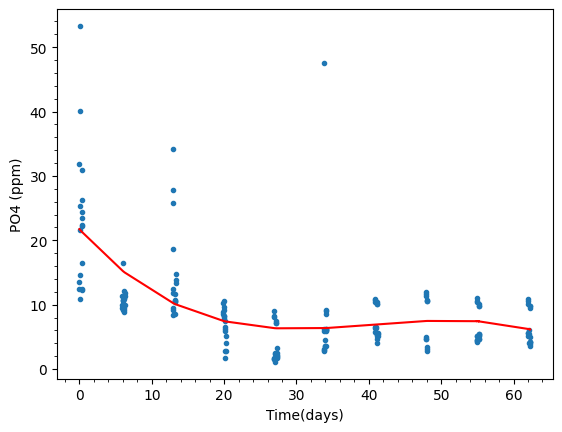

In [177]:
# separate short term & long term trends
#polyfit function just give polynomial with least squares regression
order = 3 #set the polynomial order
pp = np.polyfit(nutrients.Decimal_Time,nutrients.PO4_P,order) #fit the polynomial, pp will contain the polynomial coefficients
trend = np.polyval(pp,nutrients.Decimal_Time) #find the value of the polynomial at each time point.

plt.plot(nutrients.Decimal_Time,nutrients.PO4_P,'.') #plot the data
plt.plot(nutrients.Decimal_Time,trend,'r') #plot the trend
plt.xlabel('Time(days)') #label the x-axis
plt.ylabel('PO4 (ppm)') #label the y-axis
plt.minorticks_on() #add minorticks to the plot

Next calculate the residuals, which are the differences between the data and the fitted polynomial trend. We can compare both the trend and the residuals in a plot.

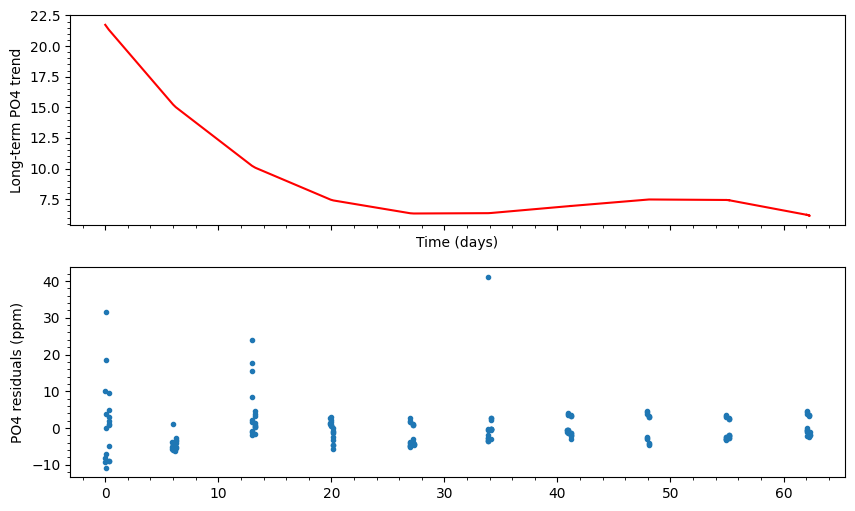

In [161]:
residuals = nutrients.PO4_P-trend #find the residuals
fig, axes = plt.subplots(2,1, figsize=(10, 6), sharex = True) #make 2 subplots with the same x-axis

axes[0].plot(nutrients.Decimal_Time,trend,'r') #plot the polynomial trend
axes[1].plot(nutrients.Decimal_Time,residuals,'.') #plot the residuals

axes[0].set_xlabel('Time (days)') #label the x-axis
axes[0].set_ylabel('Long-term PO4 trend') #label the trend y-axis
axes[1].set_ylabel('PO4 residuals (ppm)') #label the residual y-axis

axes[0].minorticks_on() #add minorticks
axes[1].minorticks_on() #add minorticks

The longer term trend is decreasing in a vaguely exponential curve. This may be attributed to increased stratification than accompanies warmer temperatures in January to March, which prevents  mixing and flux of phosphate from the deep, meaning surface waters become depleted.

These residuals represent the shorter term trends in the data, likely a result of tidal cycles. Generally the model fits well, with residuals either side of 0, though there are some extremely positive outliers.

In [ ]:
# frequency spectrum analysis

In [153]:
#Defining functions for frequency and filters
def freq_spectrum(time,signal):

  n = len(time) #number of data points

  #interpolate data onto uniformly spaced time
  x = np.linspace(np.min(time),np.max(time),n)
  y = np.interp(x,time,signal)

  sample_rate = 1 / (x[1]-x[0]) #sampling rate
  fft_vals  = np.fft.rfft(y)    #FFT (positive freqs only)
  freqs     = np.fft.rfftfreq(n, d=1/sample_rate) #frequencies

  # Amplitude: scale by 2/n so each peak height equals the true amplitude
  amplitude = (2 / n) * np.abs(fft_vals)
  amplitude[0] /= 2

  return freqs, amplitude

def lowpass_filter(time,signal,cutoff):

  n = len(time) #number of data points

    #interpolate data onto uniformly spaced time
  x = np.linspace(np.min(time),np.max(time),n)
  y = np.interp(x,time,signal)

  sample_rate = 1 / (x[1]-x[0]) #sampling rate
  fft_vals  = np.fft.rfft(y)    #FFT
  freqs     = np.fft.rfftfreq(n, d=1/sample_rate) #frequencies

  fft_vals[freqs>cutoff] = 0.0 #cycles above the frequency cutoff are given an amplitude of 0

  filtered_signal = np.fft.irfft(fft_vals, n=len(time)) #IFFT

  return x, filtered_signal


def highpass_filter(time,signal,cutoff):

  n = len(time) #number of data points

  #interpolate data onto uniformly spaced time
  x = np.linspace(np.min(time),np.max(time),n)
  y = np.interp(x,time,signal)

  sample_rate = 1 / (x[1]-x[0]) #sampling rate
  fft_vals  = np.fft.rfft(y)    #FFT
  freqs     = np.fft.rfftfreq(n, d=1/sample_rate) #frequencies

  fft_vals[freqscutoff[1]] = 0.0 #cycles above cutoff[1] are given an amplitude of 0

  filtered_signal = np.fft.irfft(fft_vals, n=len(time)) #IFFT

  return x, filtered_signal


def bandpass_filter(time,signal,cutoff):

  n = len(time) #number of data points

  #interpolate data onto uniformly spaced time
  x = np.linspace(np.min(time),np.max(time),n)
  y = np.interp(x,time,signal)

  sample_rate = 1 / (x[1]-x[0]) #sampling rate
  fft_vals  = np.fft.rfft(y)    #FFT
  freqs     = np.fft.rfftfreq(n, d=1/sample_rate) #frequencies

  fft_vals[freqs<cutoff[0]] = 0.0 #cycles below cutoff[0] are given an amplitude of 0
  fft_vals[freqs>cutoff[1]] = 0.0 #cycles above cutoff[1] are given an amplitude of 0

  filtered_signal = np.fft.irfft(fft_vals, n=len(time)) #IFFT

  return x, filtered_signal

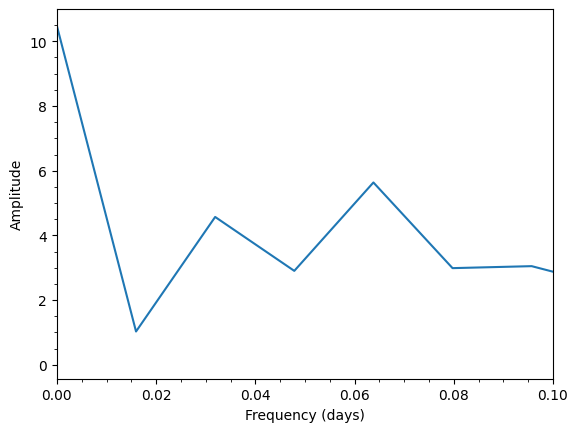

In [181]:
Time = nutrients['Decimal_Time'].values #get the age values as a numpy array
Phosphate = nutrients['PO4_P'].values #get the d18O values as a numpy array

freqs, amps = freq_spectrum(Time,Phosphate) #calculate the frequency spectrum
plt.plot(freqs,amps) #plot the frequency spectrum
plt.xlabel('Frequency (days)') #label the x-axis
plt.ylabel('Amplitude') #label the y-axis
plt.xlim([0,0.1]) #limits the x-axis
plt.minorticks_on() #add minorticks

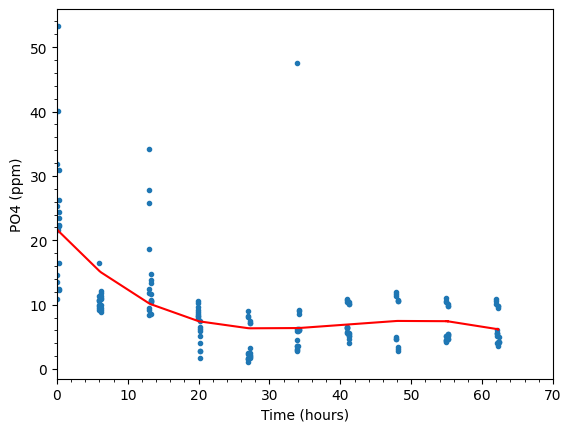

In [178]:
# detrend the data
pp = np.polyfit(Time,Phosphate,3) #fit a trendline to the data
plt.plot(Time,Phosphate,'.') #plot the original data
plt.plot(Time,np.polyval(pp,Time),'r') #plot the trendline
plt.xlabel('Time (hours)') #label the x-axis
plt.ylabel(r'PO4 (ppm)') #label the y-axis
#plt.gca().invert_yaxis() #invert the y-axis
plt.xlim([0,70]) #limit the x-axis
plt.minorticks_on() #add minorticks

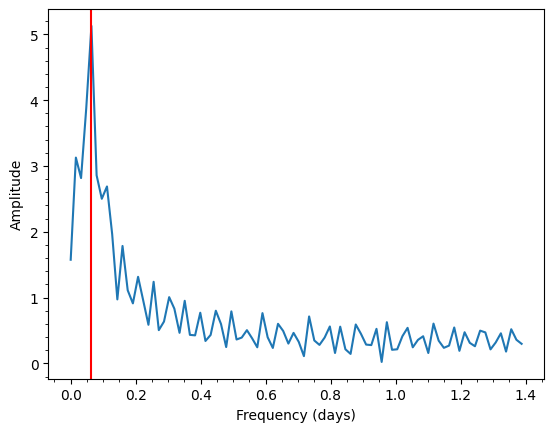

In [189]:
detrend = Phosphate-np.polyval(pp,Time) #calculate the detrended data
freqs, amps = freq_spectrum(Time,detrend) #frequency spectrum of the detrended data
plt.plot(freqs,amps) #plot the frequency spectrum
plt.xlabel('Frequency (days)') #label the x-axis
plt.ylabel('Amplitude') #label the y-axis
#plt.xlim([0,0.1]) #limits the x-axis
plt.minorticks_on() #add minorticks
plt.gca().axvline(x=0.064,color='r')

Peak at a frequency of ~0.06 days

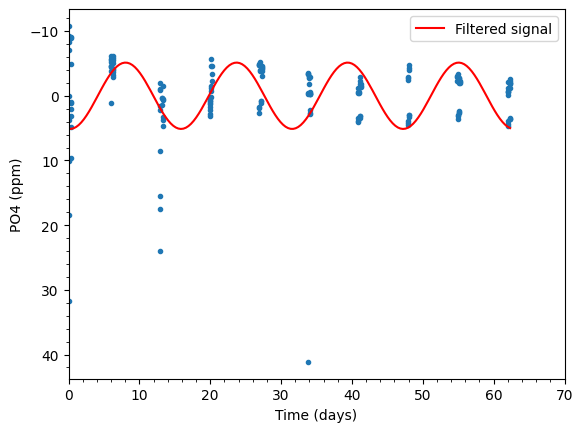

In [190]:
plt.plot(Time,detrend,'.') #plot the detrended data
x, y = bandpass_filter(Time,detrend,[0.06,0.065]) #obtain the filtered signal
plt.plot(x,y,'r', label = 'Filtered signal') #plot the filtered signal
plt.xlabel('Time (days)') #label the x-axis
plt.ylabel(r'PO4 (ppm)') #label the y-axis
plt.legend()
plt.gca().invert_yaxis() #invert the y-axis
plt.xlim([0,70]) #limit the x-axis
plt.minorticks_on() #add minorticks

The above isolated sine curve represents the effect of tides on PO4 concentrations. The period of 15 days indicates that this is most likely driven by the spring-neap tidal cycle.
This is supported by the plot below which shows a rudimentary/oversimplified version of a sine curve representing tidal cycles.

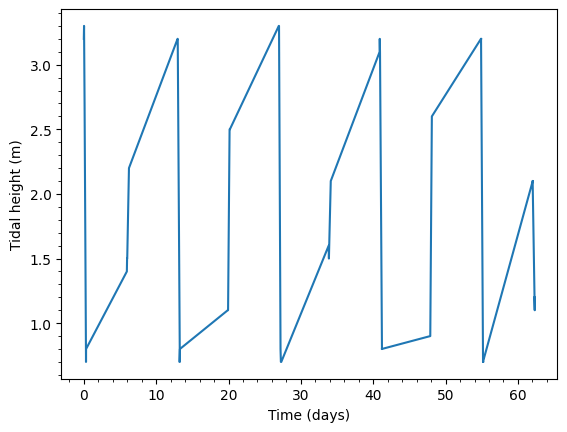

In [152]:
plt.plot(nutrients.Decimal_Time,nutrients.Tidal_height) #plot the data
plt.xlabel('Time (days)') #label the x-axis
plt.ylabel('Tidal height (m)') #label the y-axis
plt.minorticks_on() #add minorticks to the plot

Evident by visual comparison of the two previous plots, is that peaks in tide height coincide with minimums in phosphate concentration.

# Conclusions

From January to March, phosphate concentrations have an overall decreasing trend, likely due to seasonal increased temperatures and stratification causing surface waters to become depleted. The shorter term trends are primarily due to tidal cycles; the spring-neap tidal cycle has a particularly strong effect as is evident from the filtered signal with ~15 day period.

This longer term seasonal trend in phosphate has global implications. As summer temperatures become more extreme with global warming, phosphate concentrations in surface water will deplete even more significantly, slowing the biological pump and carbon cycling.




**Limitations**

This project was limited in that the dataset was only over a time frame of 3 months, so longer term trends could not be included in this analysis.
Another limitation is that the outliers cannot be accounted for/explained.
While we can infer causes for the long term trend, it would be beneficial to have quantitative data for these temperature and stratification factors.

